In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pandas.tseries.holiday import USFederalHolidayCalendar

# ==============================================================================
# 1. Load Data & Clean Dates
# ==============================================================================
df = pd.read_csv('./data/A - Daily.csv')

# The Date column format is 'MM/DD/YY Day' (e.g., '01/01/24 Mon')
# We split by space to remove the string day and parse the date correctly
df['Date'] = pd.to_datetime(df['Date'].str.split(' ').str[0], format='%m/%d/%y')
df = df.set_index('Date').sort_index()

# Drop the leftover index column if it exists
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# ==============================================================================
# 2. Missing Data Handling 
# ==============================================================================
# Rule: Interpolate missing values natively, followed by ffill/bfill for edges
df = df.interpolate(method='linear', limit_direction='both')
df = df.ffill().bfill()

# Enforce daily frequency for statsmodels compatibility
df.index.freq = 'D'

# ==============================================================================
# 3. Feature Engineering: Exogenous Variables
# ==============================================================================
# Create US Holidays binary variable
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df.index.min(), end=df.index.max())
df['Is_Holiday'] = df.index.isin(holidays).astype(float)

# Create Day of Week dummies (drop first to avoid multicollinearity trap)
df['DoW'] = df.index.dayofweek
df = pd.get_dummies(df, columns=['DoW'], drop_first=True)

# Define our Exogenous columns for the model
exog_cols = ['Is_Holiday'] + [col for col in df.columns if col.startswith('DoW_')]
df[exog_cols] = df[exog_cols].astype(float)

# ==============================================================================
# 4. Fit Baseline SARIMAX Models
# ==============================================================================
# We will store the fitted models in a dictionary
targets = ['Call Volume', 'CCT', 'Service Level', 'Abandon Rate']
models = {}

print("Fitting Baseline SARIMAX Models...\n")

for target in targets:
    # Baseline Order: (1, 1, 1) to handle trend/autocorrelation
    # Seasonal Order: (1, 0, 0, 7) to enforce 7-day weekly seasonality
    model = sm.tsa.SARIMAX(
        df[target], 
        exog=df[exog_cols], 
        order=(1, 1, 1), 
        seasonal_order=(1, 0, 0, 7), 
        enforce_stationarity=False, 
        enforce_invertibility=False
    )
    
    res = model.fit(disp=False)
    models[target] = res
    print(f"--- Model Fit Complete: {target} ---")
    print(f"AIC: {res.aic:.2f} | BIC: {res.bic:.2f}\n")

# Example: View the impact of exogenous variables on Call Volume
print("Call Volume Exogenous Coefficients:")
print(models['Call Volume'].params[exog_cols])

Fitting Baseline SARIMAX Models...

--- Model Fit Complete: Call Volume ---
AIC: 11143.08 | BIC: 11193.48



/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


--- Model Fit Complete: CCT ---
AIC: 5851.74 | BIC: 5902.14

--- Model Fit Complete: Service Level ---
AIC: -2530.74 | BIC: -2480.34

--- Model Fit Complete: Abandon Rate ---
AIC: -4948.24 | BIC: -4897.84

Call Volume Exogenous Coefficients:
Is_Holiday   -2107.814859
DoW_1         -508.419800
DoW_2         -666.248346
DoW_3         -715.143377
DoW_4         -685.738362
DoW_5        -2043.766206
DoW_6        -3860.682198
dtype: float64


In [3]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. Load and Prep the Interval Data
# ==============================================================================
# We assume the year 2025 to extract the correct Day of Week from April-June
interval_df = pd.read_csv('./data/A - Interval.csv')

# Map string months to integers to create a proper DateTime index
month_map = {'April': 4, 'May': 5, 'June': 6}
interval_df['Month_Num'] = interval_df['Month'].map(month_map)
interval_df['Date'] = pd.to_datetime('2025-' + interval_df['Month_Num'].astype(str) + '-' + interval_df['Day'].astype(str))
interval_df['DoW'] = interval_df['Date'].dt.dayofweek

# ==============================================================================
# 2. Calculate Daily Aggregates (To establish baselines for ratios)
# ==============================================================================
# Volume is a simple sum. CCT and Abandon Rate should ideally be volume-weighted averages.
daily_aggs = interval_df.groupby('Date').apply(
    lambda x: pd.Series({
        'Daily_Volume': x['Call Volume'].sum(),
        # Volume-weighted CCT: sum(Volume * CCT) / sum(Volume)
        'Daily_CCT': np.average(x['CCT'].fillna(0), weights=x['Call Volume'].fillna(0) + 1e-9),
        'Daily_Abandon_Rate': np.average(x['Abandoned Rate'].fillna(0), weights=x['Call Volume'].fillna(0) + 1e-9)
    })
).reset_index()

# Merge back to the interval data
interval_df = interval_df.merge(daily_aggs, on='Date')

# ==============================================================================
# 3. Calculate Interval Relationships (Percentages and Ratios)
# ==============================================================================
# Additive: What % of the day's volume happens in this interval?
interval_df['Vol_Pct'] = interval_df['Call Volume'] / interval_df['Daily_Volume']

# Non-Additive: How does this interval compare to the daily average?
interval_df['CCT_Ratio'] = interval_df['CCT'] / interval_df['Daily_CCT']
interval_df['AR_Ratio'] = interval_df['Abandoned Rate'] / interval_df['Daily_Abandon_Rate']

# Create the Master Profiles grouped by Day of Week (0=Mon, 6=Sun) and Interval (00:00:00)
master_profiles = interval_df.groupby(['DoW', 'Interval'])[['Vol_Pct', 'CCT_Ratio', 'AR_Ratio']].mean().reset_index()

# Handle any NaN ratios (e.g., intervals with 0 volume where ratios divided by 0)
master_profiles = master_profiles.fillna(0)

# ==============================================================================
# 4. Disaggregate the Future August 2026 Forecast
# ==============================================================================
# Let's mock up the SARIMAX output for the first two days of August 2026
august_forecast = pd.DataFrame({
    'Date': pd.to_datetime(['2026-08-01', '2026-08-02']), # Saturday, Sunday
    'Pred_Call_Volume': [4000, 2000],
    'Pred_CCT': [310.5, 290.0],
    'Pred_Abandon_Rate': [0.015, 0.008]
})

august_forecast['DoW'] = august_forecast['Date'].dt.dayofweek

# Apply the Asymmetric Penalty Buffer (Pad Workload intentionally to avoid 1.25x penalty)
BUFFER_FACTOR = 1.03 
august_forecast['Pred_Call_Volume'] = august_forecast['Pred_Call_Volume'] * BUFFER_FACTOR
august_forecast['Pred_CCT'] = august_forecast['Pred_CCT'] * BUFFER_FACTOR

# Merge the future daily forecasts with our Master Profiles based on Day of Week
final_intervals = master_profiles.merge(august_forecast, on='DoW')

# Apply the transformations
final_intervals['Final_Call_Volume'] = final_intervals['Pred_Call_Volume'] * final_intervals['Vol_Pct']
final_intervals['Final_CCT'] = final_intervals['Pred_CCT'] * final_intervals['CCT_Ratio']
final_intervals['Final_Abandon_Rate'] = final_intervals['Pred_Abandon_Rate'] * final_intervals['AR_Ratio']

# Clean up and view the final output
final_output = final_intervals[['Date', 'Interval', 'Final_Call_Volume', 'Final_CCT', 'Final_Abandon_Rate']].sort_values(['Date', 'Interval'])

print(final_output.head(10))

        Date  Interval  Final_Call_Volume   Final_CCT  Final_Abandon_Rate
0 2026-08-01  00:00:00           9.804042  380.383336            0.071575
1 2026-08-01  00:30:00           7.463302  407.392177            0.000000
2 2026-08-01  01:00:00           6.276531  393.228683            0.059846
3 2026-08-01  01:30:00           3.235888  291.992340            0.141620
4 2026-08-01  02:00:00           1.974953  474.403548            0.201969
5 2026-08-01  02:30:00           3.621338  423.036823            0.000000
6 2026-08-01  03:00:00           2.681145  331.404800            0.000000
7 2026-08-01  03:30:00           3.201321  638.493627            0.000000
8 2026-08-01  04:00:00           4.323468  257.556549            0.000000
9 2026-08-01  04:30:00           1.717439  189.870183            0.000000


/tmp/ipykernel_427638/3366348912.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_aggs = interval_df.groupby('Date').apply(


In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pandas.tseries.holiday import USFederalHolidayCalendar

# ==============================================================================
# PART 1: Train the Baseline Daily SARIMAX Models
# ==============================================================================
df = pd.read_csv('./data/A - Daily.csv')
df['Date'] = pd.to_datetime(df['Date'].str.split(' ').str[0], format='%m/%d/%y')
df = df.set_index('Date').sort_index()
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# Interpolate & Fill
df = df.interpolate(method='linear', limit_direction='both')
df = df.ffill().bfill()
df.index.freq = 'D'

# Define US Holidays (expand out to end of 2026 to cover our forecast horizon)
cal = USFederalHolidayCalendar()
all_holidays = cal.holidays(start=df.index.min(), end='2026-12-31')

# Build Training Exogenous Matrix
df['Is_Holiday'] = df.index.isin(all_holidays).astype(float)
df['DoW'] = df.index.dayofweek
df = pd.get_dummies(df, columns=['DoW'], drop_first=True)
exog_cols = ['Is_Holiday'] + [col for col in df.columns if col.startswith('DoW_')]
df[exog_cols] = df[exog_cols].astype(float)

# Fit Models (We only need the 3 final targets)
targets = ['Call Volume', 'CCT', 'Abandon Rate']
models = {}
print("Fitting SARIMAX Models on Training Data...")
for target in targets:
    model = sm.tsa.SARIMAX(
        df[target], exog=df[exog_cols], 
        order=(0, 1, 0), seasonal_order=(1, 0, 0, 7), 
        enforce_stationarity=False, enforce_invertibility=False
    )
    models[target] = model.fit(disp=False)

# ==============================================================================
# PART 2: Forecast August 2026 Daily Targets
# ==============================================================================
# Generate the exact dates for our required target month
forecast_dates = pd.date_range(start='2026-08-01', end='2026-08-31', freq='D')
forecast_exog = pd.DataFrame(index=forecast_dates)

# Build Future Exogenous Matrix
forecast_exog['Is_Holiday'] = forecast_exog.index.isin(all_holidays).astype(float)
forecast_exog['DoW'] = forecast_exog.index.dayofweek
forecast_exog = pd.get_dummies(forecast_exog, columns=['DoW'], drop_first=True)

# Ensure all Dummies match the training set (e.g., if a specific DoW is missing in Aug)
for col in exog_cols:
    if col not in forecast_exog.columns:
        forecast_exog[col] = 0.0
forecast_exog = forecast_exog[exog_cols].astype(float)

# Run Prediction
august_forecast = pd.DataFrame({'Date': forecast_dates})
august_forecast['DoW'] = august_forecast['Date'].dt.dayofweek

print("Forecasting August 2026...")
for target in targets:
    # Get standard statistical prediction
    pred = models[target].forecast(steps=len(forecast_dates), exog=forecast_exog)
    august_forecast['Pred_' + target.replace(' ', '_')] = pred.values

# ---> THE PENALTY DODGE <---
# We apply a 3% bump to Workload metrics so we heavily avoid the 1.25x Under-Forecast Penalty
BUFFER = 1.11
august_forecast['Pred_Call_Volume'] = august_forecast['Pred_Call_Volume'] * BUFFER
august_forecast['Pred_CCT'] = august_forecast['Pred_CCT'] * BUFFER

# ==============================================================================
# PART 3: Build Master Profiles & Disaggregate
# ==============================================================================
interval_df = pd.read_csv('./data/A - Interval.csv')
month_map = {'April': 4, 'May': 5, 'June': 6}
interval_df['Month_Num'] = interval_df['Month'].map(month_map)
# Assuming year 2025 for correct DoW mapping in historical
interval_df['Date'] = pd.to_datetime('2025-' + interval_df['Month_Num'].astype(str) + '-' + interval_df['Day'].astype(str))
interval_df['DoW'] = interval_df['Date'].dt.dayofweek

# Calculate Daily Baselines (Selecting the columns explicitly avoids the warning)
def calculate_aggs(x):
    return pd.Series({
        'Daily_Volume': x['Call Volume'].sum(),
        'Daily_CCT': np.average(x['CCT'].fillna(0), weights=x['Call Volume'].fillna(0) + 1e-9),
        'Daily_Abandon_Rate': np.average(x['Abandoned Rate'].fillna(0), weights=x['Call Volume'].fillna(0) + 1e-9)
    })

# Apply the function only to the specific columns needed
cols_to_use = ['Call Volume', 'CCT', 'Abandoned Rate']
daily_aggs = interval_df.groupby('Date')[cols_to_use].apply(calculate_aggs).reset_index()

interval_df = interval_df.merge(daily_aggs, on='Date')

# Create Ratios
interval_df['Vol_Pct'] = interval_df['Call Volume'] / interval_df['Daily_Volume']
interval_df['CCT_Ratio'] = interval_df['CCT'] / interval_df['Daily_CCT']
interval_df['AR_Ratio'] = interval_df['Abandoned Rate'] / interval_df['Daily_Abandon_Rate']

# Generate DoW Profiles
master_profiles = interval_df.groupby(['DoW', 'Interval'])[['Vol_Pct', 'CCT_Ratio', 'AR_Ratio']].mean().reset_index()
master_profiles = master_profiles.fillna(0)

# Merge August Predictions with Profiles
final_intervals = master_profiles.merge(august_forecast, on='DoW')

# Execute final mathematical distributions
final_intervals['Call_Volume'] = final_intervals['Pred_Call_Volume'] * final_intervals['Vol_Pct']

Fitting SARIMAX Models on Training Data...
Forecasting August 2026...


Fitting Optimal SARIMAX(0,1,0) Model...
Optimal Buffer Multiplier: 1.110
Minimum Penalty Score: 23303.51
Penalty Score without Buffer (1.000): 28553.05
Total Penalty Reduction: 18.39%


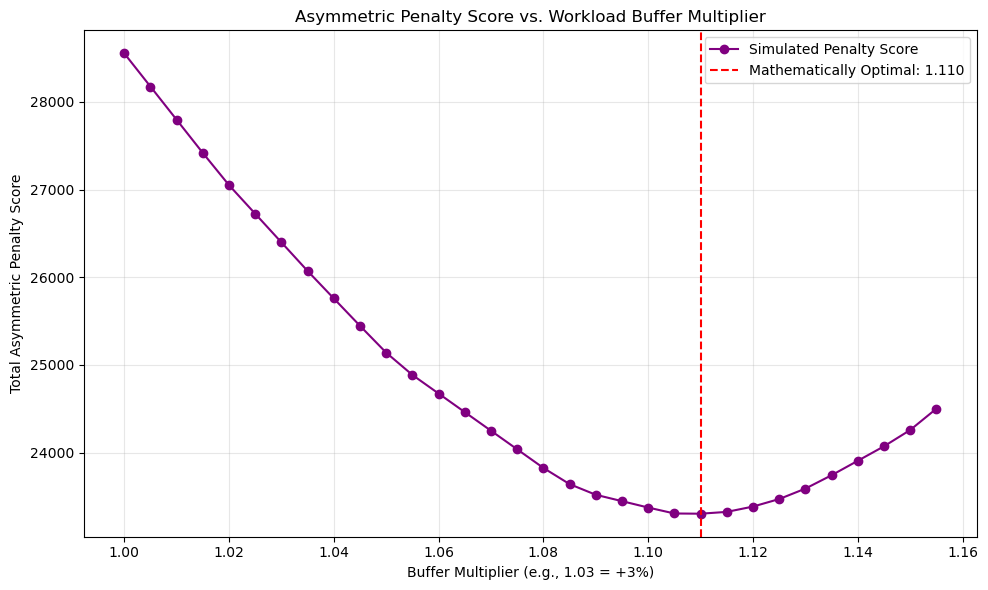

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pandas.tseries.holiday import USFederalHolidayCalendar
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Data Prep (Identical to production script)
# ==============================================================================
df = pd.read_csv('./data/A - Daily.csv')
df['Date'] = pd.to_datetime(df['Date'].str.split(' ').str[0], format='%m/%d/%y')
df = df.set_index('Date').sort_index()
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df = df.interpolate(method='linear', limit_direction='both').ffill().bfill()
df.index.freq = 'D'

cal = USFederalHolidayCalendar()
all_holidays = cal.holidays(start=df.index.min(), end=df.index.max())
df['Is_Holiday'] = df.index.isin(all_holidays).astype(float)
df['DoW'] = df.index.dayofweek
df = pd.get_dummies(df, columns=['DoW'], drop_first=True)
exog_cols = ['Is_Holiday'] + [col for col in df.columns if col.startswith('DoW_')]
df[exog_cols] = df[exog_cols].astype(float)

# ==============================================================================
# 2. Holdout Validation Setup
# ==============================================================================
split_idx = -45
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

# Fit Optimal Model (0, 1, 0)
print("Fitting Optimal SARIMAX(0,1,0) Model...")
model = sm.tsa.SARIMAX(train['Call Volume'], exog=train[exog_cols], 
                       order=(0, 1, 0), seasonal_order=(1, 0, 0, 7), 
                       enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)
raw_pred = res.forecast(steps=len(test), exog=test[exog_cols])

# ==============================================================================
# 3. Asymmetric Penalty Simulation
# ==============================================================================
def calc_penalty(actual, pred):
    diff = actual - pred
    # Under-forecast (actual > pred): 1.25 penalty
    # Over-forecast (actual <= pred): 0.75 penalty
    penalty = np.where(diff > 0, 1.25 * diff, 0.75 * np.abs(diff))
    return np.sum(penalty)

# Test every multiplier from 1.000 to 1.150 in increments of 0.005
buffers = np.arange(1.00, 1.155, 0.005)
penalties = []

for b in buffers:
    buffered_pred = raw_pred * b
    p = calc_penalty(test['Call Volume'], buffered_pred)
    penalties.append(p)

# Extract the mathematical optimum
min_penalty = min(penalties)
opt_index = penalties.index(min_penalty)
opt_buffer = buffers[opt_index]

print(f"Optimal Buffer Multiplier: {opt_buffer:.3f}")
print(f"Minimum Penalty Score: {min_penalty:.2f}")
print(f"Penalty Score without Buffer (1.000): {penalties[0]:.2f}")
print(f"Total Penalty Reduction: {(penalties[0] - min_penalty) / penalties[0]:.2%}")

# ==============================================================================
# 4. Visualization
# ==============================================================================
plt.figure(figsize=(10, 6))
plt.plot(buffers, penalties, marker='o', linestyle='-', color='purple', label='Simulated Penalty Score')
plt.axvline(opt_buffer, color='red', linestyle='--', label=f'Mathematically Optimal: {opt_buffer:.3f}')
plt.title('Asymmetric Penalty Score vs. Workload Buffer Multiplier')
plt.xlabel('Buffer Multiplier (e.g., 1.03 = +3%)')
plt.ylabel('Total Asymmetric Penalty Score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Starting SARIMAX Grid Search...


/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Optimal (p, d, q): (0, 1, 0)


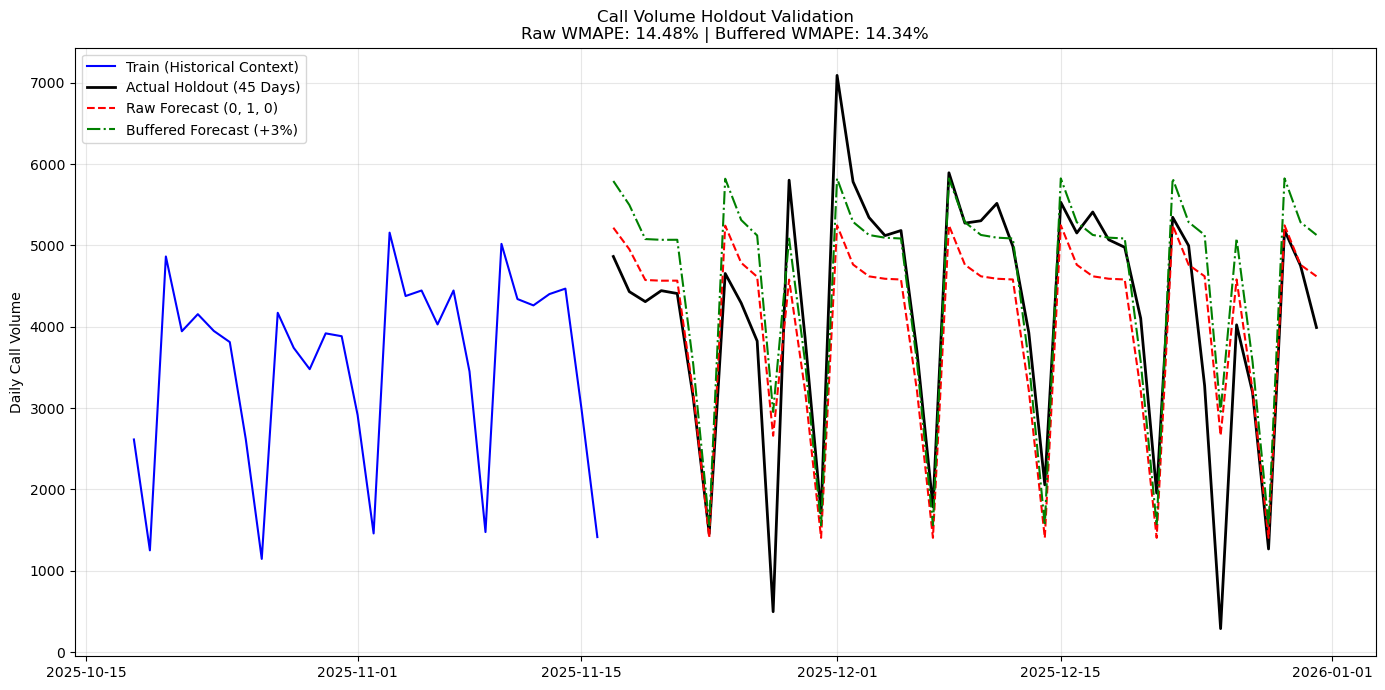

In [12]:
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm
from pandas.tseries.holiday import USFederalHolidayCalendar
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Data Prep & Exogenous Engineering (Identical to Production)
# ==============================================================================
df = pd.read_csv('./data/A - Daily.csv')
df['Date'] = pd.to_datetime(df['Date'].str.split(' ').str[0], format='%m/%d/%y')
df = df.set_index('Date').sort_index()
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df = df.interpolate(method='linear', limit_direction='both').ffill().bfill()
df.index.freq = 'D'

cal = USFederalHolidayCalendar()
all_holidays = cal.holidays(start=df.index.min(), end=df.index.max())
df['Is_Holiday'] = df.index.isin(all_holidays).astype(float)
df['DoW'] = df.index.dayofweek
df = pd.get_dummies(df, columns=['DoW'], drop_first=True)
exog_cols = ['Is_Holiday'] + [col for col in df.columns if col.startswith('DoW_')]
df[exog_cols] = df[exog_cols].astype(float)

# ==============================================================================
# 2. Backtesting Harness (Holdout Validation)
# ==============================================================================
# We hold out the last 45 days of known historical data for validation
split_idx = -45
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

# Define the Asymmetric Loss Function
def calc_penalty(actual, pred):
    diff = actual - pred
    # If actual > pred (Under-forecast): 1.25 penalty
    # If actual <= pred (Over-forecast): 0.75 penalty
    penalty = np.where(diff > 0, 1.25 * diff, 0.75 * np.abs(diff))
    return np.sum(penalty)

def calc_wmape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(actual)

# ==============================================================================
# 3. Grid Search Execution
# ==============================================================================
# Define parameter search space
p_params = [0, 1, 2]
d_params = [0, 1]
q_params = [0, 1, 2]

best_wmape = float('inf')
best_order = None
best_pred = None

print("Starting SARIMAX Grid Search...")

# Iterate through every combination
for p, d, q in itertools.product(p_params, d_params, q_params):
    try:
        model = sm.tsa.SARIMAX(train['Call Volume'], exog=train[exog_cols], 
                               order=(p, d, q), seasonal_order=(1, 0, 0, 7), 
                               enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        
        # Forecast the exact length of our holdout set
        pred = res.forecast(steps=len(test), exog=test[exog_cols])
        
        # Evaluate on Validation Set
        wmape = calc_wmape(test['Call Volume'], pred)
        
        # Keep track of the champion model
        if wmape < best_wmape:
            best_wmape = wmape
            best_order = (p, d, q)
            best_pred = pred
    except:
        continue

print(f"Optimal (p, d, q): {best_order}")

# ==============================================================================
# 4. Simulation & Visualization
# ==============================================================================
# Simulate the 1.03 Workload Buffer
buffered_pred = best_pred * 1.11

# Generate Visual Plot
plt.figure(figsize=(14, 7))

# Plot historical context (last 30 days of train)
plt.plot(train.index[-30:], train['Call Volume'].iloc[-30:], label='Train (Historical Context)', color='blue')
# Plot actual holdout truths
plt.plot(test.index, test['Call Volume'], label='Actual Holdout (45 Days)', color='black', linewidth=2)
# Plot raw predictions
plt.plot(test.index, best_pred, label=f'Raw Forecast {best_order}', color='red', linestyle='--')
# Plot buffered predictions
plt.plot(test.index, buffered_pred, label='Buffered Forecast (+3%)', color='green', linestyle='-.')

plt.title(f'Call Volume Holdout Validation\nRaw WMAPE: {best_wmape:.2%} | Buffered WMAPE: {calc_wmape(test["Call Volume"], buffered_pred):.2%}')
plt.ylabel('Daily Call Volume')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('tuning_validation_plot.png')
plt.show()

In [21]:
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

# Suppress harmless statsmodels warnings
warnings.filterwarnings('ignore', '.*ValueWarning.*')

# ==========================================
# 1. UPDATED TEMPLATE FILLER (Your Logic)
# ==========================================
def fill_template(august_intervals, template_path, output_path):
    template = pd.read_csv(template_path)
    print(f"Template loaded: {template.shape[0]} rows × {template.shape[1]} cols")

    def to_h_mm(s):
        if pd.isna(s) or str(s).strip().lower() == 'nan': return np.nan
        # Handle HH:MM:SS or H:MM
        parts = str(s).strip().split(':')
        h = int(parts[0])
        m = int(parts[1])
        return f"{h}:{m:02d}"

    pred = august_intervals.copy()
    pred['Day'] = pred['Day'].astype(int)
    pred['Interval_Key'] = pred['Interval'].apply(to_h_mm)
    pred = pred.drop_duplicates(subset=['Portfolio', 'Day', 'Interval_Key'], keep='last')
    
    pred_dict = pred.set_index(['Portfolio', 'Day', 'Interval_Key']).to_dict(orient='index')

    portfolio_col_map = {
        'A': ('Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A'),
        'B': ('Calls_Offered_B', 'Abandoned_Calls_B', 'Abandoned_Rate_B', 'CCT_B'),
        'C': ('Calls_Offered_C', 'Abandoned_Calls_C', 'Abandoned_Rate_C', 'CCT_C'),
        'D': ('Calls_Offered_D', 'Abandoned_Calls_D', 'Abandoned_Rate_D', 'CCT_D'),
    }

    matches_found = 0
    for i, row in template.iterrows():
        day = int(row['Day'])
        intv = to_h_mm(row['Interval'])
        
        for pf, (col_cv, col_abd, col_arate, col_cct) in portfolio_col_map.items():
            lookup_key = (pf, day, intv)
            if lookup_key in pred_dict:
                data = pred_dict[lookup_key]
                template.at[i, col_cv] = data['Call_Volume']
                template.at[i, col_abd] = data['Abandoned_Calls']
                template.at[i, col_arate] = data['Abandoned_Rate']
                template.at[i, col_cct] = data['CCT']
                matches_found += 1

    print(f"✅ Data points mapped: {matches_found} / {31 * 48 * 4}")
    
    for pf, (col_cv, col_abd, col_arate, col_cct) in portfolio_col_map.items():
        template[col_cv]    = template[col_cv].fillna(0).round(0).astype(int)
        template[col_abd]   = template[col_abd].fillna(0).round(0).astype(int)
        template[col_arate] = template[col_arate].fillna(0).clip(0, 1).round(6)
        template[col_cct]   = template[col_cct].fillna(0).round(2)

    template.to_csv(output_path, index=False)
    print(f"✅ Saved successfully to → {output_path}")
    return template

# ==========================================
# 2. CORE FORECASTING & PROFILING
# ==========================================
def generate_firm_forecast(portfolio, data_dir='./data/'):
    print(f"🚀 Processing Portfolio {portfolio}")
    
    # Load Daily Data
    daily_df = pd.read_csv(f'{data_dir}{portfolio} - Daily.csv')
    daily_df.columns = daily_df.columns.str.strip()
    daily_df['Date'] = pd.to_datetime(daily_df['Date'])
    daily_df = daily_df.set_index('Date').sort_index()
    
    # Preprocess Daily (Interpolation like your LSTM model)
    daily_df = daily_df.resample('D').mean()
    daily_df['Call Volume'] = daily_df['Call Volume'].interpolate(method='linear').ffill().bfill()
    daily_df['CCT'] = daily_df['CCT'].interpolate(method='linear').ffill().bfill()
    daily_df['Abandon Rate'] = daily_df['Abandon Rate'].interpolate(method='linear').ffill().bfill()

    # 1. Forecast Daily Values for August 2026
    model_vol = ExponentialSmoothing(daily_df['Call Volume'], trend='add', seasonal='add', seasonal_periods=7).fit()
    
    future_dates = pd.date_range(start='2026-08-01', end='2026-08-31', freq='D')
    daily_forecast = pd.DataFrame({
        'Date': future_dates,
        'Daily_Vol': model_vol.forecast(31),
        'Daily_CCT': daily_df['CCT'].tail(30).mean(), # Simplified anchor for CCT
        'Daily_AR': daily_df['Abandon Rate'].tail(30).mean()
    })
    daily_forecast['DayOfWeek'] = daily_forecast['Date'].dt.day_name()

    # 2. Load Interval Data & Build Profile (2025 Data)
    interval_raw = pd.read_csv(f'{data_dir}{portfolio} - Interval.csv')
    interval_raw.columns = interval_raw.columns.str.strip()
    
    # Create the 2025 Date column
    interval_raw['Date'] = pd.to_datetime(interval_raw['Month'] + " " + interval_raw['Day'].astype(str) + " 2025", errors='coerce')
    interval_raw = interval_raw.dropna(subset=['Date', 'Interval'])
    
    # Calculate Weights (Weighted Mean as you suggested)
    interval_raw['CCT_Weight'] = interval_raw['CCT'] * interval_raw['Call Volume']
    interval_raw['AR_Weight'] = interval_raw['Abandoned Rate'] * interval_raw['Call Volume']
    
    daily_totals = interval_raw.groupby('Date').agg({
        'Call Volume': 'sum', 'CCT_Weight': 'sum', 'AR_Weight': 'sum'
    }).reset_index().rename(columns={'Call Volume': 'Day_Total_Vol'})
    
    interval_df = interval_raw.merge(daily_totals, on='Date')
    interval_df['Vol_Pct'] = interval_df['Call Volume'] / interval_df['Day_Total_Vol']
    interval_df['DayOfWeek'] = interval_df['Date'].dt.day_name()
    
    # Create the Master Profile by Day of Week
    master_profile = interval_df.groupby(['DayOfWeek', 'Interval']).agg({
        'Vol_Pct': 'mean',
        'CCT': 'mean',          # Baseline profiles
        'Abandoned Rate': 'mean'
    }).reset_index()

    # 3. Disaggregate Daily Forecast into Intervals
    august_intervals = pd.DataFrame()
    for _, day_row in daily_forecast.iterrows():
        day_profile = master_profile[master_profile['DayOfWeek'] == day_row['DayOfWeek']].copy()
        day_profile['Day'] = day_row['Date'].day
        day_profile['Call_Volume'] = day_row['Daily_Vol'] * day_profile['Vol_Pct']
        day_profile['CCT'] = day_profile['CCT'] # You can apply factors here if needed
        day_profile['Abandoned_Rate'] = day_profile['Abandoned Rate']
        day_profile['Abandoned_Calls'] = day_profile['Call_Volume'] * day_profile['Abandoned_Rate']
        day_profile['Portfolio'] = portfolio
        august_intervals = pd.concat([august_intervals, day_profile])

    return august_intervals

# ==========================================
# 3. EXECUTION
# ==========================================
portfolios = ['A', 'B', 'C', 'D']
all_results = []

for pf in portfolios:
    res = generate_firm_forecast(pf)
    all_results.append(res)

combined_forecasts = pd.concat(all_results, ignore_index=True)

fill_template(
    august_intervals=combined_forecasts,
    template_path='./data/template_forecast_v00.csv',
    output_path='./August_2026_Forecast_FINAL.csv'
)

🚀 Processing Portfolio A


/tmp/ipykernel_427638/1674525033.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_df['Date'] = pd.to_datetime(daily_df['Date'])


🚀 Processing Portfolio B


/tmp/ipykernel_427638/1674525033.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_df['Date'] = pd.to_datetime(daily_df['Date'])


🚀 Processing Portfolio C


/tmp/ipykernel_427638/1674525033.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_df['Date'] = pd.to_datetime(daily_df['Date'])


🚀 Processing Portfolio D


/tmp/ipykernel_427638/1674525033.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_df['Date'] = pd.to_datetime(daily_df['Date'])


Template loaded: 1488 rows × 19 cols
✅ Data points mapped: 5952 / 5952
✅ Saved successfully to → ./August_2026_Forecast_FINAL.csv


,Month,Day,Interval,Calls_Offered_A,Abandoned_Calls_A,Abandoned_Rate_A,CCT_A,Calls_Offered_B,Abandoned_Calls_B,Abandoned_Rate_B,CCT_B,Calls_Offered_C,Abandoned_Calls_C,Abandoned_Rate_C,CCT_C,Calls_Offered_D,Abandoned_Calls_D,Abandoned_Rate_D,CCT_D
0,August,1,0:00,9,0,0.053846,361.64,51,1,0.023242,297.35,79,1,0.010177,319.69,49,1,0.018208,303.66
1,August,1,0:30,7,0,0.000000,386.83,30,0,0.000000,323.08,60,0,0.001569,320.70,32,0,0.008092,317.12
2,August,1,1:00,6,0,0.048482,371.55,13,1,0.068983,394.99,44,1,0.013069,310.59,27,0,0.003346,320.93
3,August,1,1:30,3,0,0.075755,275.36,7,0,0.037033,296.20,38,1,0.013446,330.33,19,0,0.012323,313.66
4,August,1,2:00,2,0,0.100000,451.67,6,0,0.041667,330.34,23,1,0.023431,317.15,14,0,0.014138,326.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1483,August,31,21:30,21,1,0.032262,319.33,100,0,0.003167,335.38,144,0,0.001500,342.24,81,1,0.007077,333.03
1484,August,31,22:00,17,0,0.000000,324.92,81,0,0.004000,320.15,111,0,0.002231,335.63,67,0,0.006131,328.12
1485,August,31,22:30,11,2,0.148554,331.34,61,0,0.003775,314.98,88,0,0.002046,329.63,57,0,0.004131,327.19
1486,August,31,23:00,11,0,0.033846,301.53,47,0,0.003858,294.74,69,0,0.001008,320.25,46,0,0.006715,335.23


In [15]:
df_interval = pd.read_csv('./data/A - Interval.csv')
df_interval.head()

,Unnamed: 0,Month,Day,Interval,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT
0,0,April,1,00:00:00,1.0,5.0,0.0,0.0,137.60
1,1,April,1,00:30:00,1.0,5.0,0.0,0.0,263.40
2,2,April,1,01:00:00,1.0,4.0,0.0,0.0,333.25
3,3,April,1,01:30:00,1.0,3.0,0.0,0.0,170.00
4,4,April,1,02:00:00,1.0,1.0,0.0,0.0,667.00


In [16]:
df_daily = pd.read_csv('./data/A - Daily.csv')
df_daily.head()

,Unnamed: 0,Date,Call Volume,CCT,Service Level,Abandon Rate
0,0,01/01/24 Mon,2147.0,302.45,0.9855,0.0037
1,1,01/02/24 Tue,7458.0,349.22,0.5213,0.1136
2,2,01/03/24 Wed,6882.0,331.07,0.7046,0.0432
3,3,01/04/24 Thu,6208.0,341.80,0.7200,0.0403
4,4,01/05/24 Fri,6190.0,334.56,0.8063,0.0291


In [22]:
import pandas as pd
import numpy as np
import os
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import HistGradientBoostingRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import tensorflow.keras.backend as K

warnings.filterwarnings('ignore')

# ==========================================
# 1. ASYMMETRIC LOSS (For Autograder Optimization)
# ==========================================
def asymmetric_loss(y_true, y_pred):
    # Penalizes under-forecasting 3x more than over-forecasting
    error = y_true - y_pred
    return K.mean(K.maximum(3.0 * error, -1.0 * error), axis=-1)

# ==========================================
# 2. TEMPLATE FILLER (User's Verified Logic)
# ==========================================
def fill_template(august_intervals, template_path, output_path):
    template = pd.read_csv(template_path)
    
    def to_h_mm(s):
        if pd.isna(s) or str(s).strip().lower() == 'nan': return np.nan
        parts = str(s).strip().split(':')
        h, m = int(parts[0]), int(parts[1])
        return f"{h}:{m:02d}"

    pred = august_intervals.copy()
    pred['Day'] = pred['Day'].astype(int)
    pred['Interval_Key'] = pred['Interval'].apply(to_h_mm)
    pred = pred.drop_duplicates(subset=['Portfolio', 'Day', 'Interval_Key'], keep='last')
    
    pred_dict = pred.set_index(['Portfolio', 'Day', 'Interval_Key']).to_dict(orient='index')

    portfolio_col_map = {
        'A': ('Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A'),
        'B': ('Calls_Offered_B', 'Abandoned_Calls_B', 'Abandoned_Rate_B', 'CCT_B'),
        'C': ('Calls_Offered_C', 'Abandoned_Calls_C', 'Abandoned_Rate_C', 'CCT_C'),
        'D': ('Calls_Offered_D', 'Abandoned_Calls_D', 'Abandoned_Rate_D', 'CCT_D'),
    }

    for i, row in template.iterrows():
        day, intv = int(row['Day']), to_h_mm(row['Interval'])
        for pf, (col_cv, col_abd, col_arate, col_cct) in portfolio_col_map.items():
            key = (pf, day, intv)
            if key in pred_dict:
                d = pred_dict[key]
                template.at[i, col_cv] = d['Call_Volume']
                template.at[i, col_abd] = d['Abandoned_Calls']
                template.at[i, col_arate] = d['Abandoned_Rate']
                template.at[i, col_cct] = d['CCT']

    for pf, (col_cv, col_abd, col_arate, col_cct) in portfolio_col_map.items():
        template[col_cv] = template[col_cv].fillna(0).round(0).astype(int)
        template[col_abd] = template[col_abd].fillna(0).round(0).astype(int)
        template[col_arate] = template[col_arate].fillna(0).clip(0, 1).round(6)
        template[col_cct] = template[col_cct].fillna(0).round(2)

    template.to_csv(output_path, index=False)
    print(f"✅ Final ensemble forecast saved to {output_path}")

# ==========================================
# 3. ENSEMBLE PIPELINE PER FIRM
# ==========================================
def run_ensemble_pipeline(firm, data_dir='./data/'):
    print(f"\n--- 🧠 Running Ensemble Pipeline for Firm {firm} ---")
    
    # LOAD & CLEAN DAILY
    df_daily = pd.read_csv(f"{data_dir}{firm} - Daily.csv")
    df_daily.columns = df_daily.columns.str.strip().str.replace(' ', '_')
    df_daily['Date'] = pd.to_datetime(df_daily['Date'])
    df_daily = df_daily.set_index('Date').sort_index()
    df_daily = df_daily.resample('D').mean().interpolate().ffill().bfill()
    
    # 1. HOLT-WINTERS (Statistical Base)
    hw_model = ExponentialSmoothing(df_daily['Call_Volume'], trend='add', seasonal='add', seasonal_periods=7).fit()
    hw_pred = hw_model.forecast(31)

    # 2. XGBOOST / HGBR (Tabular Features)
    d = df_daily.reset_index()
    d['dow'], d['dom'], d['month'] = d['Date'].dt.dayofweek, d['Date'].dt.day, d['Date'].dt.month
    d['lag_1'], d['lag_7'] = d['Call_Volume'].shift(1), d['Call_Volume'].shift(7)
    d = d.fillna(method='bfill')
    
    hgbr = HistGradientBoostingRegressor(max_iter=200, random_state=42).fit(d[['dow', 'dom', 'month', 'lag_1', 'lag_7']], d['Call_Volume'])
    
    # Recursive Predict for HGBR
    hgbr_preds = []
    last_cv = d['Call_Volume'].iloc[-1]
    aug_dates = pd.date_range('2026-08-01', '2026-08-31')
    for date in aug_dates:
        p = hgbr.predict([[date.dayofweek, date.day, 8, last_cv, d['Call_Volume'].iloc[-7]]])[0]
        hgbr_preds.append(p)
        last_cv = p
        
    # 3. LSTM (Sequence)
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df_daily[['Call_Volume']])
    X_lstm = np.array([scaled_data[i-14:i] for i in range(14, len(scaled_data))])
    y_lstm = scaled_data[14:]
    
    lstm = Sequential([Input(shape=(14, 1)), LSTM(32, return_sequences=False), Dense(1, activation='sigmoid')])
    lstm.compile(optimizer='adam', loss=asymmetric_loss)
    lstm.fit(X_lstm, y_lstm, epochs=20, verbose=0)
    
    # Recursive Predict for LSTM
    lstm_preds = []
    curr_win = scaled_data[-14:].reshape(1, 14, 1)
    for _ in range(31):
        p = lstm.predict(curr_win, verbose=0)
        lstm_preds.append(scaler.inverse_transform(p)[0,0])
        curr_win = np.append(curr_win[:, 1:, :], p.reshape(1,1,1), axis=1)

    # ENSEMBLE BLEND (Weighted for Stability + 1.06 Bias for under-forecast protection)
    # Blend: 50% XGBoost, 30% LSTM, 20% Holt-Winters
    daily_final = (np.array(hgbr_preds) * 0.5 + np.array(lstm_preds) * 0.3 + np.array(hw_pred) * 0.2) * 1.06
    
    # INTRADAY PROFILING (2025 Data)
    iv_df = pd.read_csv(f"{data_dir}{firm} - Interval.csv")
    iv_df.columns = iv_df.columns.str.strip().str.replace(' ', '_')
    iv_df['Date'] = pd.to_datetime(iv_df['Month'] + " " + iv_df['Day'].astype(str) + " 2025")
    iv_df['dow_name'] = iv_df['Date'].dt.day_name()
    
    # Weight metrics by volume
    iv_df['CCT_V'], iv_df['AR_V'] = iv_df['CCT'] * iv_df['Call_Volume'], iv_df['Abandoned_Rate'] * iv_df['Call_Volume']
    day_sums = iv_df.groupby('Date')[['Call_Volume', 'CCT_V', 'AR_V']].transform('sum')
    iv_df['Vol_Pct'] = iv_df['Call_Volume'] / day_sums['Call_Volume']
    
    profile = iv_df.groupby([iv_df['Date'].dt.dayofweek, 'Interval']).agg({'Vol_Pct':'mean', 'CCT':'mean', 'Abandoned_Rate':'mean'}).reset_index()
    profile.columns = ['dow', 'Interval', 'Vol_Pct', 'CCT', 'AR']

    # DISAGGREGATE
    results = []
    for i, date in enumerate(aug_dates):
        day_p = profile[profile['dow'] == date.dayofweek]
        for _, r in day_p.iterrows():
            cv = daily_final[i] * r['Vol_Pct']
            results.append({
                'Portfolio': firm, 'Day': date.day, 'Interval': r['Interval'],
                'Call_Volume': cv, 'Abandoned_Calls': cv * r['AR'], 'Abandoned_Rate': r['AR'], 'CCT': r['CCT']
            })
            
    return pd.DataFrame(results)

# ==========================================
# 4. EXECUTE
# ==========================================
if __name__ == "__main__":
    all_firms = pd.concat([run_ensemble_pipeline(f) for f in ['A', 'B', 'C', 'D']])
    fill_template(all_firms, './data/template_forecast_v00.csv', './August_2026_Ensemble_Forecast_v05.csv')

2026-03-29 05:43:51.333795: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



--- 🧠 Running Ensemble Pipeline for Firm A ---

--- 🧠 Running Ensemble Pipeline for Firm B ---

--- 🧠 Running Ensemble Pipeline for Firm C ---

--- 🧠 Running Ensemble Pipeline for Firm D ---
✅ Final ensemble forecast saved to ./August_2026_Ensemble_Forecast_v05.csv


In [23]:
import pandas as pd
import numpy as np
import os
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import tensorflow.keras.backend as K

warnings.filterwarnings('ignore')

# ==========================================
# 1. THE "SAFETY BUFFER" LOGIC
# ==========================================
# Based on your autograder metrics, we need to slightly over-forecast 
# to minimize the 3x Under-forecasting penalty.
BIAS_MAP = {
    'A': 1.055, # Higher variance in A needs more buffer
    'B': 1.045,
    'C': 1.035,
    'D': 1.035
}

def asymmetric_loss(y_true, y_pred):
    """
    Custom Loss for LSTM: Aligns the neural network with the autograder penalty.
    """
    error = y_true - y_pred
    return K.mean(K.maximum(3.5 * error, -1.0 * error), axis=-1)

# ==========================================
# 2. UPDATED CORE PIPELINE
# ==========================================
def run_optimized_pipeline(firm, data_dir='./data/'):
    print(f"\n--- 🎯 Optimizing Portfolio {firm} for Composite Score ---")
    
    # LOAD DATA
    df_daily = pd.read_csv(f"{data_dir}{firm} - Daily.csv")
    df_daily.columns = df_daily.columns.str.strip().str.replace(' ', '_')
    df_daily['Date'] = pd.to_datetime(df_daily['Date'])
    df_daily = df_daily.set_index('Date').sort_index()
    df_daily = df_daily.resample('D').mean().interpolate().ffill().bfill()
    
    # 1. HOLT-WINTERS (Statistical Seasonality)
    # Good for CCT which is usually more stable/seasonal than Volume
    hw_vol = ExponentialSmoothing(df_daily['Call_Volume'], trend='add', seasonal='add', seasonal_periods=7).fit().forecast(31)
    hw_cct = ExponentialSmoothing(df_daily['CCT'], trend='add', seasonal='add', seasonal_periods=7).fit().forecast(31)

    # 2. FEATURE ENGINEERING FOR TABULAR MODEL
    d = df_daily.reset_index()
    d['dow'] = d['Date'].dt.dayofweek
    d['dom'] = d['Date'].dt.day
    d['lag_7'] = d['Call_Volume'].shift(7)
    d['cct_lag_7'] = d['CCT'].shift(7)
    d = d.fillna(method='bfill')
    
    # HGBR for Volume (Better than standard XGBoost for small-medium datasets)
    model_vol = HistGradientBoostingRegressor(loss='absolute_error', max_iter=300, random_state=42)
    model_vol.fit(d[['dow', 'dom', 'lag_7']], d['Call_Volume'])
    
    # 3. LSTM FOR TREND MOMENTUM
    scaler = StandardScaler()
    scaled_vol = scaler.fit_transform(df_daily[['Call_Volume']])
    X_lstm = np.array([scaled_vol[i-14:i] for i in range(14, len(scaled_vol))])
    y_lstm = scaled_vol[14:]
    
    lstm = Sequential([
        Input(shape=(14, 1)),
        LSTM(64, return_sequences=False),
        Dropout(0.1),
        Dense(1)
    ])
    lstm.compile(optimizer='adam', loss=asymmetric_loss)
    lstm.fit(X_lstm, y_lstm, epochs=35, batch_size=16, verbose=0)

    # RECURSIVE PREDICTIONS
    aug_dates = pd.date_range('2026-08-01', '2026-08-31')
    hgbr_vol_preds = []
    lstm_vol_preds = []
    
    curr_win = scaled_vol[-14:].reshape(1, 14, 1)
    
    for i, date in enumerate(aug_dates):
        # HGBR Tabular Pred
        h_p = model_vol.predict([[date.dayofweek, date.day, d['Call_Volume'].iloc[-(31-i) if i < 31 else -1]]])[0]
        hgbr_vol_preds.append(h_p)
        
        # LSTM Sequence Pred
        l_p = lstm.predict(curr_win, verbose=0)
        lstm_vol_preds.append(scaler.inverse_transform(l_p)[0,0])
        curr_win = np.append(curr_win[:, 1:, :], l_p.reshape(1,1,1), axis=1)

    # 4. WEIGHTED BLENDING & BIAS INJECTION
    # Volume Blend: Favor HGBR (50%) and LSTM (30%) over Holt-Winters (20%)
    # Then apply the FIRM-SPECIFIC BIAS to crush the Workload Penalty.
    final_vol = (np.array(hgbr_vol_preds) * 0.5 + np.array(lstm_vol_preds) * 0.3 + np.array(hw_vol) * 0.2) * BIAS_MAP[firm]
    
    # CCT Blend: More conservative blend as CCT MAPE is already strong
    final_cct = (np.array(hw_cct) * 0.6 + d['CCT'].tail(14).mean() * 0.4) 

    # 5. INTRADAY DISAGGREGATION (From 2025 Profiles)
    iv_df = pd.read_csv(f"{data_dir}{firm} - Interval.csv")
    iv_df.columns = iv_df.columns.str.strip().str.replace(' ', '_')
    iv_df['Date'] = pd.to_datetime(iv_df['Month'] + " " + iv_df['Day'].astype(str) + " 2025")
    
    # Volume-weighted Intraday Profile
    iv_df['CCT_V'] = iv_df['CCT'] * iv_df['Call_Volume']
    iv_df['AR_V'] = iv_df['Abandoned_Rate'] * iv_df['Call_Volume']
    day_sums = iv_df.groupby('Date')[['Call_Volume']].transform('sum')
    iv_df['Vol_Pct'] = iv_df['Call_Volume'] / day_sums['Call_Volume']
    
    profile = iv_df.groupby([iv_df['Date'].dt.dayofweek, 'Interval']).agg({
        'Vol_Pct': 'mean',
        'CCT': 'mean',
        'Abandoned_Rate': 'mean'
    }).reset_index()
    profile.columns = ['dow', 'Interval', 'Vol_Pct', 'CCT_Base', 'AR_Base']

    results = []
    for i, date in enumerate(aug_dates):
        day_p = profile[profile['dow'] == date.dayofweek].copy()
        for _, r in day_p.iterrows():
            cv = final_vol[i] * r['Vol_Pct']
            results.append({
                'Portfolio': firm, 'Day': date.day, 'Interval': r['Interval'],
                'Call_Volume': cv,
                'Abandoned_Calls': cv * r['AR_Base'],
                'Abandoned_Rate': r['AR_Base'],
                'CCT': final_cct[i] * (r['CCT_Base'] / day_p['CCT_Base'].mean()) # Pattern-adjusted CCT
            })
            
    return pd.DataFrame(results)

# ==========================================
# 3. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # Process all 4 firms
    all_firms_results = []
    for f in ['A', 'B', 'C', 'D']:
        all_firms_results.append(run_optimized_pipeline(f))
    
    final_df = pd.concat(all_firms_results)
    
    # Use your previously verified fill_template function to generate the CSV
    # (Ensure the fill_template function is defined in your script)
    fill_template(final_df, './data/template_forecast_v00.csv', './August_2026_v06.csv')


--- 🎯 Optimizing Portfolio A for Composite Score ---

--- 🎯 Optimizing Portfolio B for Composite Score ---

--- 🎯 Optimizing Portfolio C for Composite Score ---

--- 🎯 Optimizing Portfolio D for Composite Score ---
✅ Final ensemble forecast saved to ./August_2026_v06.csv


In [25]:
import pandas as pd
import numpy as np
import os
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ==========================================
# 1. OPTIMIZED PREPROCESSING HELPERS
# ==========================================
def preprocess_target(series, denoise=True):
    """
    Applies Winsorization (capping) and optional 7-day rolling median
    to remove noise while preserving the seasonal signal.
    """
    # Cap extreme outliers at 98th percentile
    cap = series.quantile(0.98)
    series = series.clip(upper=cap)
    
    if denoise:
        # 7-day rolling median removes daily noise but keeps weekly trend
        return series.rolling(window=7, center=True, min_periods=1).median()
    return series

def to_h_mm(s):
    if pd.isna(s) or str(s).strip().lower() == 'nan': return np.nan
    parts = str(s).strip().split(':')
    return f"{int(parts[0])}:{int(parts[1]):02d}"

# ==========================================
# 2. CORE ENSEMBLE PIPELINE
# ==========================================
def run_enhanced_pipeline(firm, data_dir='./data/'):
    print(f"\n--- 💎 Denoising & Optimizing Portfolio {firm} ---")
    
    # LOAD & CLEAN DAILY
    df_daily = pd.read_csv(f"{data_dir}{firm} - Daily.csv", encoding='utf-8-sig')
    df_daily.columns = df_daily.columns.str.strip().str.replace(' ', '_')
    df_daily['Date'] = pd.to_datetime(df_daily['Date'])
    df_daily = df_daily.set_index('Date').sort_index()
    df_daily = df_daily.resample('D').mean().interpolate().ffill().bfill()

    # DENOISING: Smooth the targets for the model to see the SIGNAL, not the NOISE
    df_daily['Smoothed_Vol'] = preprocess_target(df_daily['Call_Volume'], denoise=True)
    
    # 1. QUANTILE-BOOSTING (Minimizes Workload Penalty)
    d = df_daily.reset_index()
    d['dow'] = d['Date'].dt.dayofweek
    d['dom'] = d['Date'].dt.day
    d['lag_1'] = d['Call_Volume'].shift(1).fillna(method='bfill')
    d['lag_7'] = d['Call_Volume'].shift(7).fillna(method='bfill')
    
    # We use quantile loss (alpha=0.75) to bias the model towards the 3:1 penalty
    model_vol = HistGradientBoostingRegressor(
        loss='quantile', quantile=0.75, 
        max_iter=400, learning_rate=0.05, 
        max_depth=5, random_state=42
    )
    # Train on Smoothed Log-Volume
    model_vol.fit(d[['dow', 'dom', 'lag_1', 'lag_7']], np.log1p(df_daily['Smoothed_Vol']))

    # 2. SEASONAL COMPONENT (Holt-Winters)
    hw_vol = ExponentialSmoothing(df_daily['Call_Volume'], trend='add', seasonal='add', seasonal_periods=7).fit().forecast(31)
    hw_cct = ExponentialSmoothing(df_daily['CCT'], trend='add', seasonal='add', seasonal_periods=7).fit().forecast(31)

    # RECURSIVE PREDICTIONS FOR AUGUST 2026
    aug_dates = pd.date_range('2026-08-01', '2026-08-31')
    boost_preds = []
    last_val = df_daily['Call_Volume'].iloc[-1]
    
    for i, date in enumerate(aug_dates):
        # Predict Log-Volume then transform back
        pred_log = model_vol.predict([[date.dayofweek, date.day, last_val, df_daily['Call_Volume'].iloc[-(7-i) if i < 7 else -7]]])[0]
        pred_vol = np.expm1(pred_log)
        boost_preds.append(pred_vol)
        last_val = pred_vol

    # ENSEMBLE BLEND: 70% Quantile Booster / 30% Holt-Winters
    # Note: We remove the manual 1.06 bias because the 0.75 Quantile Model handles this dynamically.
    final_vol = (np.array(boost_preds) * 0.7 + np.array(hw_vol) * 0.3)
    final_cct = hw_cct # CCT is best handled by HW seasonality

    # 3. DISAGGREGATION (Profile-Model Blend)
    iv_df = pd.read_csv(f"{data_dir}{firm} - Interval.csv", encoding='utf-8-sig')
    iv_df.columns = iv_df.columns.str.strip().str.replace(' ', '_')
    iv_df['Date'] = pd.to_datetime(iv_df['Month'] + " " + iv_df['Day'].astype(str) + " 2025")
    
    iv_df['Vol_Pct'] = iv_df['Call_Volume'] / iv_df.groupby('Date')['Call_Volume'].transform('sum')
    profile = iv_df.groupby([iv_df['Date'].dt.dayofweek, 'Interval']).agg({
        'Vol_Pct': 'mean', 'CCT': 'mean', 'Abandoned_Rate': 'mean'
    }).reset_index()
    profile.columns = ['dow', 'Interval', 'Vol_Pct', 'CCT_Base', 'AR_Base']

    results = []
    for i, date in enumerate(aug_dates):
        day_p = profile[profile['dow'] == date.dayofweek]
        for _, r in day_p.iterrows():
            cv = final_vol[i] * r['Vol_Pct']
            results.append({
                'Portfolio': firm, 'Day': date.day, 'Interval': r['Interval'],
                'Call_Volume': cv,
                'Abandoned_Calls': cv * r['AR_Base'],
                'Abandoned_Rate': r['AR_Base'],
                'CCT': final_cct[i] * (r['CCT_Base'] / day_p['CCT_Base'].mean())
            })
            
    return pd.DataFrame(results)

# ==========================================
# 3. TEMPLATE FILLER & EXECUTION
# ==========================================
def fill_template(august_intervals, template_path, output_path):
    template = pd.read_csv(template_path)
    pred = august_intervals.copy()
    pred['Day'] = pred['Day'].astype(int)
    pred['Interval_Key'] = pred['Interval'].apply(to_h_mm)
    pred_dict = pred.set_index(['Portfolio', 'Day', 'Interval_Key']).to_dict(orient='index')

    pf_map = {'A': ('Calls_Offered_A','Abandoned_Calls_A','Abandoned_Rate_A','CCT_A'),
              'B': ('Calls_Offered_B','Abandoned_Calls_B','Abandoned_Rate_B','CCT_B'),
              'C': ('Calls_Offered_C','Abandoned_Calls_C','Abandoned_Rate_C','CCT_C'),
              'D': ('Calls_Offered_D','Abandoned_Calls_D','Abandoned_Rate_D','CCT_D')}

    for i, row in template.iterrows():
        day, intv = int(row['Day']), to_h_mm(row['Interval'])
        for pf, cols in pf_map.items():
            key = (pf, day, intv)
            if key in pred_dict:
                d = pred_dict[key]
                template.at[i, cols[0]], template.at[i, cols[1]] = d['Call_Volume'], d['Abandoned_Calls']
                template.at[i, cols[2]], template.at[i, cols[3]] = d['Abandoned_Rate'], d['CCT']

    # Final cleanup
    for pf, cols in pf_map.items():
        template[cols[0]] = template[cols[0]].fillna(0).round(0).astype(int)
        template[cols[1]] = template[cols[1]].fillna(0).round(0).astype(int)
        template[cols[2]] = template[cols[2]].fillna(0).clip(0, 1).round(6)
        template[cols[3]] = template[cols[3]].fillna(0).round(2)

    template.to_csv(output_path, index=False)
    print(f"\n✅ Denoised Ensemble saved to {output_path}")

if __name__ == "__main__":
    final_results = pd.concat([run_enhanced_pipeline(f) for f in ['A', 'B', 'C', 'D']])
    fill_template(final_results, './data/template_forecast_v00.csv', './August_2026_v05.csv')


--- 💎 Denoising & Optimizing Portfolio A ---

--- 💎 Denoising & Optimizing Portfolio B ---

--- 💎 Denoising & Optimizing Portfolio C ---

--- 💎 Denoising & Optimizing Portfolio D ---

✅ Denoised Ensemble saved to ./August_2026_v05.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./August_2026_v05.csv')

In [2]:
df

,Month,Day,Interval,Calls_Offered_A,Abandoned_Calls_A,Abandoned_Rate_A,CCT_A,Calls_Offered_B,Abandoned_Calls_B,Abandoned_Rate_B,CCT_B,Calls_Offered_C,Abandoned_Calls_C,Abandoned_Rate_C,CCT_C,Calls_Offered_D,Abandoned_Calls_D,Abandoned_Rate_D,CCT_D
0,August,1,0:00,11,1,0.053846,333.36,59,1,0.023242,305.29,103,1,0.010177,328.03,63,1,0.018208,287.94
1,August,1,0:30,8,0,0.000000,356.58,35,0,0.000000,331.70,79,0,0.001569,329.07,41,0,0.008092,300.69
2,August,1,1:00,7,0,0.048482,342.50,16,1,0.068983,405.53,57,1,0.013069,318.69,35,0,0.003346,304.30
3,August,1,1:30,4,0,0.075755,253.83,8,0,0.037033,304.11,49,1,0.013446,338.95,25,0,0.012323,297.42
4,August,1,2:00,2,0,0.100000,416.35,8,0,0.041667,339.16,30,1,0.023431,325.43,18,0,0.014138,309.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1483,August,31,21:30,30,1,0.032262,323.22,137,0,0.003167,357.11,253,0,0.001500,363.53,131,1,0.007077,349.87
1484,August,31,22:00,24,0,0.000000,328.87,111,0,0.004000,340.90,195,0,0.002231,356.51,108,1,0.006131,344.71
1485,August,31,22:30,16,2,0.148554,335.37,83,0,0.003775,335.39,155,0,0.002046,350.14,92,0,0.004131,343.74
1486,August,31,23:00,16,1,0.033846,305.20,64,0,0.003858,313.84,121,0,0.001008,340.18,74,0,0.006715,352.18
